# Phase 2a-2. DEG analysis & paper marker overlap validation

이 notbook의 목적은 TAM subtype annoation 이후 각 subtype을 특징짓는 DEG(Differentially Expressed Genes)를 찾고 논문에서 제시한 maker gene과 overlap되는지 검증하는 것이다.

핵심 질문:
- C1QC+ TAM과 SPP1+ TAM은 실제로 서로 다른 transcriptional signiture를 가지는가?
- 논문 marker gene이 GSE127465 폐암 데이터에서도 DEG 상위권에 재현되는가?

## 0. 왜 annoation 이후 DEG 분석을 다시 하는가?

Annoation은 marker gene 기반으로 cluster에 이름을 붙이는 interpretation 단계다.

반면 DEG 분석은 각 cluster/subtype을 특징짓는 gene이 실제 데이터에서 통계적으로 유의미하게 높게 발현되는지 확인하는 단계이다.

즉:
- annotatio: known marker를 보고 이름을 붙임
- DEG: 이 그룹을 가장 잘 설명하는 gene signature를 데이터에서 다시 찾음

따라서 DEG는 annotation의 근거를 강화하고 논문 marker와의 재현성을 검증하는 역할을 한다

In [1]:

import scanpy as sc
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *

mac = sc.read_h5ad(MAC_SUB_H5AD)

print(mac)
print(mac.obs['tam_subtype'].value_counts())
print('raw exists:', mac.raw is not None)
print('raw shape:', None if mac.raw is None else mac.raw.shape)

AnnData object with n_obs × n_vars = 9567 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type', 'C1QC_score', 'SPP1_score', 'tam_subtype'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'tam_subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
tam_subtype
Unknown                  4566
C1QC+ TAM               

## 1. DEG 실행

`rank_gene_groups`는 group별로 해당 group에서 상대적으로 더 높게 발현되는 gene을 ranking한다

여기서는 `tam_subtype`을 기준으로 C1QC+ TAM, SPP1+ TAM, C1QC+ TAM(tentative), SPP1+ TAM(tentative), Unknown을 비교한다.

`method='wilcoxon'`을 사용하는 이유:
- scRNA-seq 데이터는 0이 많고(sparse) 분포가 정규분포를 따르지 않는 경우가 많다
- Wilcoxon rank-sum test는 rank 기반 비교라 이런 분포에 비교적 robust하다

`use_raw=True`를 사용하는 이유:
- HVG filltering 이후 `adata.X`에는 일부 gene만 남아 있을 수 있다
- marker/DEG 해석에는 raw normalized matrix 기준 gene expression을 쓰는 것이 안전하다

DEG result keys: dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])


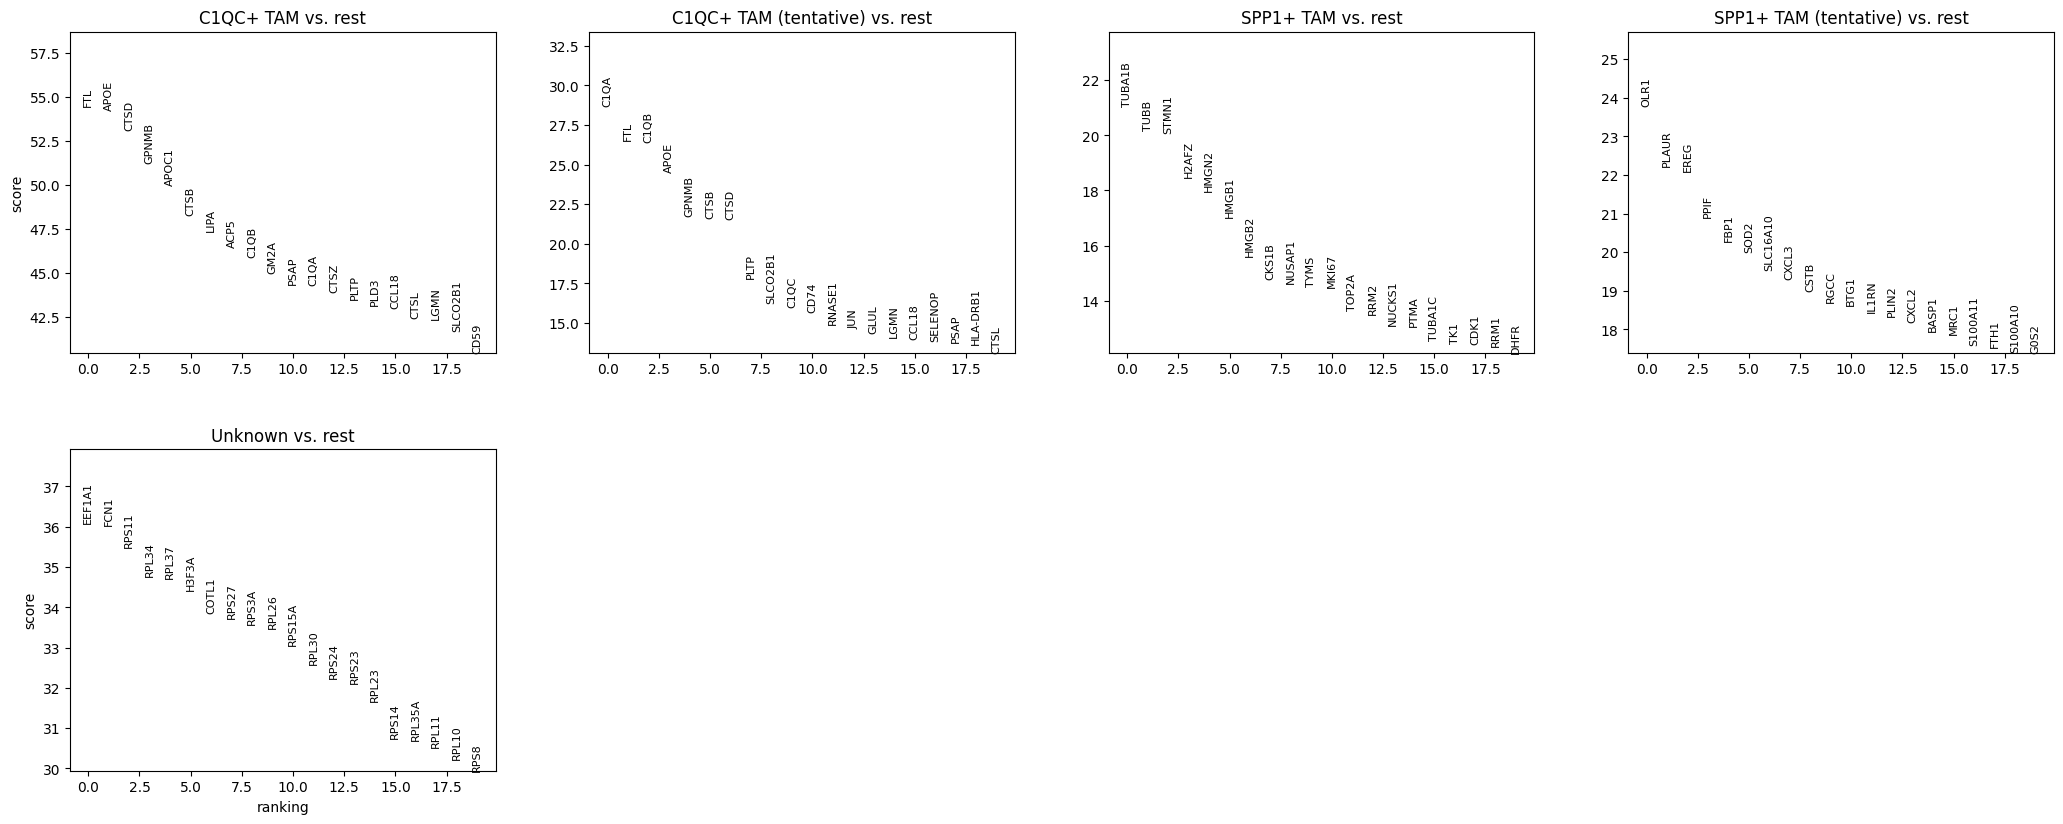

In [2]:
sc.tl.rank_genes_groups(
    mac,
    groupby='tam_subtype',
    method='wilcoxon',
    key_added='deg_tam',
    use_raw=True
)

print('DEG result keys:', mac.uns['deg_tam'].keys())
sc.pl.rank_genes_groups(mac, n_genes=20, key='deg_tam', sharey=False)

## 2. DEG 결과 table로 확인

plot만으로는 개별 유전자의 발현 차이와 통계적 유의성을 정량적으로 확인하기 어렵기 때문에 각 subtype의 DEG 결과를 dataframe으로 추출하였다.

주요 확인 항목:
- names: DEG gene name
- logfoldchanges: 다른 subtype 대비 발현 증가 정도 (log2 fold change)
- pvals_adj: multiple testing correction 이후의 adjusted p-value
- scores: Wilcoxon rank-sum test statistic

이후 논문 Supplementary Table S3의 DEG signature와 비교하기 위해 상위 DEG를 추출하여 사용하였다.

In [3]:
deg_tables = {}
for group in mac.obs['tam_subtype'].cat.categories if hasattr(mac.obs['tam_subtype'], 'cat') else sorted(mac.obs['tam_subtype'].unique()):
    df = sc.get.rank_genes_groups_df(mac, group=group, key='deg_tam')
    deg_tables[group] = df
    print(f"===== {group} top 10 DEG =====")
    display(df[['names', 'logfoldchanges', 'pvals_adj', 'scores']].head(10))

===== C1QC+ TAM top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,FTL,2.285938,0.0,54.485142
1,APOE,4.622464,0.0,54.205784
2,CTSD,3.084746,0.0,53.068287
3,GPNMB,3.506784,0.0,51.190434
4,APOC1,3.814516,0.0,49.974525
5,CTSB,2.287833,0.0,48.267513
6,LIPA,2.962007,0.0,47.348675
7,ACP5,2.964721,0.0,46.424377
8,C1QB,3.313667,0.0,45.857906
9,GM2A,2.547320,0.0,44.982185


===== C1QC+ TAM (tentative) top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,C1QA,2.430425,8.936845e-177,28.720198
1,FTL,1.365724,7.522630e-151,26.537355
2,C1QB,2.276568,5.971243e-150,26.443981
3,APOE,2.463979,2.067039e-128,24.488159
4,GPNMB,1.811132,6.077330e-101,21.739359
5,CTSB,1.294826,5.045568e-100,21.623283
6,CTSD,1.650530,2.316785e-99,21.547949
7,PLTP,1.890072,5.980273e-68,17.850645
8,SLCO2B1,1.398341,3.586028e-56,16.243479
9,C1QC,1.655975,2.347637e-54,15.976919


===== SPP1+ TAM top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,TUBA1B,3.004869,6.179542e-94,21.070736
1,TUBB,3.479646,2.547894e-86,20.189236
2,STMN1,4.681184,2.291662e-85,20.060257
3,H2AFZ,3.446168,3.804086e-72,18.469490
4,HMGN2,2.818919,3.434479e-68,17.958712
5,HMGB1,2.510302,2.530744e-61,17.047832
6,HMGB2,3.127481,4.138069e-51,15.603235
7,CKS1B,4.589078,8.721972e-46,14.791307
8,NUSAP1,5.932498,7.316469e-45,14.639464
9,TYMS,7.209290,3.789697e-44,14.519984


===== SPP1+ TAM (tentative) top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,OLR1,2.123437,1.617436e-120,23.793886
1,PLAUR,1.669575,4.467512e-105,22.221373
2,EREG,2.159916,3.885599e-104,22.105719
3,PPIF,1.791423,5.033136e-93,20.905125
4,FBP1,2.010571,1.808297e-87,20.274498
5,SOD2,1.512285,4.291041e-85,19.994490
6,SLC16A10,1.782977,3.651163e-81,19.529987
7,CXCL3,1.986726,2.400863e-79,19.308138
8,CSTB,1.525287,7.914589e-77,19.000118
9,RGCC,1.716956,1.842711e-74,18.706261


===== Unknown top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,EEF1A1,0.544169,5.017258e-282,36.077923
1,FCN1,3.638461,1.634391e-281,36.044548
2,RPS11,0.821021,5.606140e-273,35.493038
3,RPL34,1.104067,4.343820e-262,34.777115
4,RPL37,0.905753,2.259261e-261,34.729160
5,H3F3A,0.931364,1.121032e-256,34.416145
6,COTL1,1.304708,3.812337e-248,33.839954
7,RPS27,0.964956,1.606377e-246,33.728802
8,RPS3A,1.034567,1.846676e-244,33.587444
9,RPL26,1.013604,5.517890e-243,33.485725


## 3. Supplementary Table S3 DEG signature 비교

각 subtype의 DEG를 비교하여 논문에서 보고된 transcriptional program이 GSE127465에서도 재현되는지 평가하였다.

이 검증의 의미:
- 단순히 UMAP에서 비슷해 보이는 것이 아니라 논문에서 제시한 TAM subtype별 DEG signature가 내 데이터에서도 관찰되는지 확인
- marker gene 몇 개의 존재 여부가 아닌 subtype-level transcriptional program의 유사성을 평가
- tentative subtype을 별도로 유지하여 annotation confidence를 비교 

In [10]:
# Supplementary Table S3 기반 TAM subtype DEG signature
# 각 list는 Table S3에서 avg_log2FC 내림차순 top gene 사용

paper_signatures = {
    'Resting C1QC+ TAMs': [
        'SELENOP', 'APOC1', 'C1QB', 'C1QA', 'NUPR1',
        'C1QC', 'VSIG4', 'APOE', 'TREM2', 'GPNMB',
        'HLA-DPB1', 'HLA-DPA1', 'CTSD', 'HLA-DQB1', 'HLA-DRA',
        'ALOX5AP', 'HLA-DMA', 'CD63', 'FTL', 'HLA-DRB1',
        'CD74', 'TMSB4X', 'ITM2B', 'NPC2'
    ],

    'Activated C1QC+ TAMs': [
        'SELENOP', 'FOLR2', 'SLC40A1', 'RNASE1', 'PLTP',
        'DAB2', 'C1QC', 'LILRB5', 'SLCO2B1', 'LGMN',
        'C1QB', 'C1QA', 'PLAU', 'A2M', 'F13A1',
        'MAF', 'GPR34', 'MRC1', 'IGF1', 'APOE',
        'GAL3ST4', 'RGS1', 'LTC4S', 'MS4A4A', 'GAS6',
        'FILIP1L', 'NRP1', 'STAB1', 'MERTK', 'GPNMB'
    ],

    'SPP1+ TAMs': [
        'FN1', 'SPP1', 'INHBA', 'CXCL3', 'MT1X',
        'FABP5', 'SDC2', 'CCL20', 'MARCO'
    ],

    'ISG15+ TAMs': [
        'CXCL10', 'CXCL11', 'CXCL9', 'IDO1', 'IFIT1',
        'RSAD2', 'IFIT2', 'ISG15', 'GBP1'
    ],
}


def clean_gene(x):
    return str(x).strip().upper()


overlap_rows = []

my_groups = (
    mac.obs["tam_subtype"].cat.categories
    if hasattr(mac.obs["tam_subtype"], "cat")
    else sorted(mac.obs["tam_subtype"].unique())
)

for my_group in my_groups:
    deg = sc.get.rank_genes_groups_df(
        mac,
        group=my_group,
        key="deg_tam"
    ).copy()

    # Scanpy rank_genes_groups_df는 이미 ranking 순서로 반환되므로
    # 여기서는 logfoldchanges로 재정렬하지 않고 상위 50개를 사용
    deg["gene_clean"] = deg["names"].map(clean_gene)
    deg["rank"] = deg.index + 1

    my_top = deg.head(50).copy()

    for paper_signature, paper_genes in paper_signatures.items():
        paper_gene_set = {clean_gene(g) for g in paper_genes}

        matched = my_top.loc[
            my_top["gene_clean"].isin(paper_gene_set),
            ["names", "rank", "logfoldchanges", "pvals_adj"]
        ].copy()

        overlap_rows.append({
            "my_subtype": my_group,
            "paper_signature": paper_signature,
            "paper_signature_size": len(paper_gene_set),
            "my_top_n": len(my_top),
            "overlap_count": len(matched),
            "overlap_ratio": len(matched) / len(paper_gene_set),
            "overlap_genes": ", ".join(matched["names"].tolist()),
            "overlap_ranks": ", ".join(matched["rank"].astype(str).tolist())
        })

overlap_df = pd.DataFrame(overlap_rows)

display(
    overlap_df.sort_values(
        ["my_subtype", "overlap_count", "overlap_ratio"],
        ascending=[True, False, False]
    )
)

,my_subtype,paper_signature,paper_signature_size,my_top_n,overlap_count,overlap_ratio,overlap_genes,overlap_ranks
0,C1QC+ TAM,Resting C1QC+ TAMs,24,50,11,0.458333,"FTL, APOE, CTSD, GPNMB, APOC1, C1QB, C1QA, CD6...","1, 2, 3, 4, 5, 9, 12, 23, 31, 39, 42"
1,C1QC+ TAM,Activated C1QC+ TAMs,30,50,11,0.366667,"APOE, GPNMB, C1QB, C1QA, PLTP, LGMN, SLCO2B1, ...","2, 4, 9, 12, 14, 18, 19, 22, 30, 34, 44"
2,C1QC+ TAM,SPP1+ TAMs,9,50,0,0.000000,,
3,C1QC+ TAM,ISG15+ TAMs,9,50,0,0.000000,,
4,C1QC+ TAM (tentative),Resting C1QC+ TAMs,24,50,17,0.708333,"C1QA, FTL, C1QB, APOE, GPNMB, CTSD, C1QC, CD74...","1, 2, 3, 4, 5, 7, 10, 11, 17, 19, 21, 26, 29, ..."
5,C1QC+ TAM (tentative),Activated C1QC+ TAMs,30,50,13,0.433333,"C1QA, C1QB, APOE, GPNMB, PLTP, SLCO2B1, C1QC, ...","1, 3, 4, 5, 8, 9, 10, 12, 15, 17, 36, 48, 50"
6,C1QC+ TAM (tentative),SPP1+ TAMs,9,50,0,0.000000,,
7,C1QC+ TAM (tentative),ISG15+ TAMs,9,50,0,0.000000,,
10,SPP1+ TAM,SPP1+ TAMs,9,50,1,0.111111,SPP1,49
8,SPP1+ TAM,Resting C1QC+ TAMs,24,50,1,0.041667,ALOX5AP,36


## 4. overlap table 정량 검증

- C1QC+ TAM과 C1QC+ TAM (tentative)는 논문 Resting/Activated C1QC+ TAM signature와 overlap을 보이는지 확인한다.
- SPP1+ TAM 계열은 논문 SPP1+ TAM signature와의 overlap 여부를 확인한다.
- Unknown은 특정 TAM signature와 overlap이 낮은지 확인한다.

In [11]:
best_overlap = (
    overlap_df
    .sort_values(
        ["my_subtype", "overlap_count", "overlap_ratio"],
        ascending=[True, False, False]
    )
    .groupby("my_subtype", as_index=False)
    .first()
)

display(best_overlap)

,my_subtype,paper_signature,paper_signature_size,my_top_n,overlap_count,overlap_ratio,overlap_genes,overlap_ranks
0,C1QC+ TAM,Resting C1QC+ TAMs,24,50,11,0.458333,"FTL, APOE, CTSD, GPNMB, APOC1, C1QB, C1QA, CD6...","1, 2, 3, 4, 5, 9, 12, 23, 31, 39, 42"
1,C1QC+ TAM (tentative),Resting C1QC+ TAMs,24,50,17,0.708333,"C1QA, FTL, C1QB, APOE, GPNMB, CTSD, C1QC, CD74...","1, 2, 3, 4, 5, 7, 10, 11, 17, 19, 21, 26, 29, ..."
2,SPP1+ TAM,SPP1+ TAMs,9,50,1,0.111111,SPP1,49
3,SPP1+ TAM (tentative),SPP1+ TAMs,9,50,2,0.222222,"CXCL3, SPP1","8, 31"
4,Unknown,Resting C1QC+ TAMs,24,50,0,0.000000,,


In [14]:
overlap_df.to_csv(
    "docs/results/tam_signature_overlap_all.csv",
    index=False
)

best_overlap.to_csv(
    "docs/results/tam_signature_overlap_best.csv",
    index=False
)

C1QC-associated cluster는 논문 Resting/Activated C1QC+ TAMs DEG signature와 46~71% overlap을 보였다.
SPP1-associated cluster는 Table S3 기준 overlap 수치가 낮으나, dotplot에서 SPP1, FN1, INHBA, CXCL3 등 SPP1+ TAMs의 핵심 marker의 발현이 확인되었다. 이는 DEG 비교기준(전체 골수계 세포 vs 내 서브타입 간 비교)의 차이에서 기인하는 것으로 해석된다.

## 5. TAM subtype signature dotplot

Supplementary Table S3에서 정리한 subtype-specific DEG signature 중 대표 유전자를 선별하여 dotplot으로 시각화하였다.

이를 통해 DEG overlap에서 확인 된 subtype 별 signature가 실제 expression pattern에서도 일관되게 나타나는지 검토하였다.

- C1QC-like cluster는 C1QA, C1QB, C1QC, APOE, GPNMB 등의 C1QC-associated signature를 확인
- Activated C1QC 관련 유전자인 FOLR2, PLTP, MRC1 발현을 추가 검토
- SPP1-like cluster는 SPP1, FN1, INHBA, CXCL3 등의 SPP1-associated signature를 기준으로 검토
- ISG15-related signature는 단일 폐암 데이터에서 뚜렷한 cluster로 분리되는지 확인

Dotplot 해석:
- 점 크기: 해당 group에서 그 gene을 발현하는 cell fraction
- 색 진하기: 해당 group 내 평균 발현량
- standard_scale='var': gene별 상대적 발현 패턴을 비교하기 쉽게 scaling

available: ['SELENOP', 'APOC1', 'C1QA', 'C1QB', 'C1QC', 'VSIG4', 'APOE', 'GPNMB', 'FOLR2', 'PLTP', 'SLC40A1', 'RNASE1', 'LGMN', 'MRC1', 'SPP1', 'FN1', 'INHBA', 'CXCL3', 'FABP5', 'CCL20', 'MARCO', 'CXCL10', 'CXCL11', 'CXCL9', 'IDO1', 'IFIT1', 'RSAD2', 'ISG15', 'GBP1']
missing: []


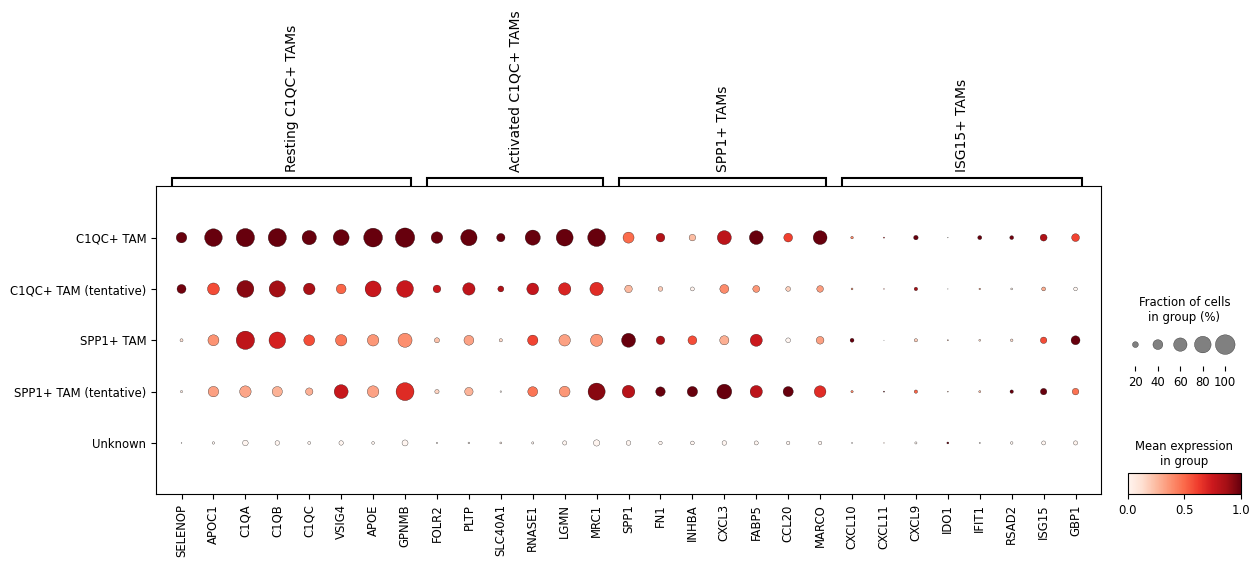

In [15]:
dotplot_markers = {
    "Resting C1QC+ TAMs": [
        "SELENOP", "APOC1", "C1QA", "C1QB", "C1QC", "VSIG4", "APOE", "GPNMB"
    ],
    "Activated C1QC+ TAMs": [
        "FOLR2", "PLTP", "SLC40A1", "RNASE1", "LGMN", "MRC1"
    ],
    "SPP1+ TAMs": [
        "SPP1", "FN1", "INHBA", "CXCL3", "FABP5", "CCL20", "MARCO"
    ],
    "ISG15+ TAMs": [
        "CXCL10", "CXCL11", "CXCL9", "IDO1", "IFIT1", "RSAD2", "ISG15", "GBP1"
    ],
}

all_dotplot_genes = [
    gene
    for genes in dotplot_markers.values()
    for gene in genes
]

available_genes = [
    g for g in all_dotplot_genes
    if g in mac.raw.var_names
]

missing_genes = [
    g for g in all_dotplot_genes
    if g not in mac.raw.var_names
]

print("available:", available_genes)
print("missing:", missing_genes)

sc.pl.dotplot(
    mac,
    var_names=dotplot_markers,
    groupby="tam_subtype",
    use_raw=True,
    standard_scale="var",
    dendrogram=False,
    figsize=(14, 4),
    show=True
)

### dotplot 결과 해석

- C1QC+ TAM 및 C1QC+ TAM (tentative)은 C1QA/C1QB/C1QC/APOE/GPNMB 등 C1QC-associated signature를 공유하였다.
- SPP1+ TAM 계열은 SPP1/FABP5/INHBA/CXCL3 등 SPP1-associated signature를 나타냈다.
- 반면 ISG15-associated signature는 GSE127465 단일 폐암 데이터에서 뚜렷하게 관찰되지 않았다.

이는 단일 암종 데이터의 한계로 해석되며, 이후 pan-cancer 데이터(GSE154763)에서 추가 검증하겠다.

## 5. Biology interpretation note

### C1QC-associated TAM

- C1QA, C1QB, C1QC, APOE, SELENOP, FOLR2 등이 높게 발현된다.
- 논문에서는 Resting C1QC+ TAM 및 Activated C1QC+ TAM으로 구분되며, phagocytosis, complement activation, tissue homeostasis와 연관된 macrophage program을 나타낸다.
- GSE127465에서도 동일한 C1QC-associated signature가 관찰되었으며, resident macrophage 계열과 유사한 특성을 보였다.

### SPP1-associated TAM

- SPP1, FN1, INHBA, CXCL3, FABP5 등의 발현이 상대적으로 높게 나타난다.
- 논문에서는 angiogenesis, extracellular matrix (ECM) remodeling, inflammatory response와 연관된 macrophage program으로 기술된다.
- GSE127465에서도 SPP1-associated signature가 관찰되었으며, C1QC-associated TAM과는 구별되는 transcriptional state를 보였다.

### Interpretation

두 subtype 모두 macrophage 계열 세포이지만, 서로 다른 transcriptional program과 기능적 상태(functional state)를 가진다.

C1QC-associated TAM은 조직 항상성 및 포식 작용(phagocytosis)에 가까운 특성을 보이는 반면, SPP1-associated TAM은 조직 재구성(remodeling), 혈관신생(angiogenesis), 염증 반응과 연관된 특성을 보인다.

따라서 TAM은 하나의 균질한 세포군이 아니라, 서로 다른 기능적 상태를 갖는 macrophage subtype의 집합으로 해석할 수 있다.

In [16]:
mac.write(MAC_PH2_H5AD)
print(f'저장 완료: {MAC_PH2_H5AD}')

저장 완료: dataset\GSE127465_mac_phase2a.h5ad
